In [3]:
import numpy as np
import time
import random
import matplotlib.pyplot as plt

In [4]:
# ----- Gradient Descent Implementation -----

In [5]:
class SampleModel:
    """ class for sample model with parameters a,b """
    
    def __init__(self, a=0.5, b=0.5):
        """
        Initialize coefficient and bias

        Inputs:
        - a: coef
        - b: bias
        """
        self.params = {'coef':a, 'bias':b}

    def data_generation(self, true_a, true_b):
        """
        Generate dataset
        """
        self.true_a = true_a
        self.true_b = true_b

        N = 100000

        X = np.random.randn(N)
        random_noise = np.random.randn(N) / 10

        X_modified = X + random_noise

        y = self.true_a*X_modified + self.true_b

        return X, y

    def data_generation_quad(self, true_a, true_b):
        """
        Generate dataset
        """
        self.true_a = true_a
        self.true_b = true_b

        N = 100000

        X = np.random.randn(N)
        random_noise = np.random.randn(N) / 10

        X_modified = X + random_noise

        y = np.power(self.true_a*X_modified + self.true_b, 2)

        return X, y

    def forward(self, X):
        """
        Implement forward pass for the model
        """
        a, b = self.params['coef'], self.params['bias']
        y = a * X + b
        return y

    def backward(self, X, y):
        """
        Computes the gradients for each param in self.params
        @param X: training input data (N,)
        @param y: training output data (N,)
        @return: gradients of parameters
        """
        a, b = self.params['coef'], self.params['bias']

        gradients = {}     ## Loss(L2) = avg((y - (a*X + b))^2)
        gradients['coef'] = np.mean(2*(y - (a*X+b))*(-X))
        gradients['bias']  = np.mean(2*(y - (a*X+b))*(-1))

        return gradients

    def run(self, X, y, train=False, n_epochs=10, lr=0.001, batch_size=None):
        """
        Runs the model with training as an option.
        @param X: training input data (N,)
        @param y: training output data (N,)
        @train: boolean for train
        @n_epochs: number of traninig epochs
        @lr: learning rate
        """
        print("Training Starts...")
        if train:
            if batch_size:
                print("Mini-Batch SGD w Batch Size: {}".format(batch_size))
                self.batch_gradient_descent(X, y, n_epochs=n_epochs, lr=lr, batch_size=batch_size)
            
            else:
                print("Full-Batch GD")
                self.gradient_descent(X, y, n_epochs=n_epochs, lr=lr)

    def gradient_descent(self, X, y, n_epochs=10, lr=0.001):
        """
        Train using batch gradient descent.
        @param X: training input data (N,)
        @param y: training output data (N,)
        @param lr: learning rate
        """
        loss_list = []
        first = 100000000
        
        for epoch in range(n_epochs):
            gradients = self.backward(X, y)
            for param in self.params:
                self.params[param] -= lr * gradients[param]
            
            # 연속되는 epoch 간 loss difference를 계산하고 loss의 변화를 기록하기 위한 코드를 추가함
            second = self.compute_loss(X,y)
            diff = (first - second) / first
            first = second
            loss_list.append(second)
        
            print("========== Epoch {}/{} ==========".format(epoch+1, n_epochs))
            print("Loss > {:.15f}".format(self.compute_loss(X,y)))
            print("Params > coef: {:.2f} / bias: {:.2f}".format(self.params['coef'], self.params['bias']))
            print("Loss Difference between Successive Epochs:",round(diff*100,3),"%")
            
            if diff < 0.01 and diff > -0.01:
                break
        plt.plot(loss_list, marker='o')
        plt.title('Full-Batch GD')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Value')
        plt.show()

    def batch_gradient_descent(self, X, y, n_epochs=10, lr=0.001, batch_size=16):
        """
        Train using batch gradient descent.
        @param X: training input data (N,)
        @param y: training output data (N,)
        @param lr: learning rate
        @param batch_size
        """
        first = 100000000
        loss_list = []
        
        for epoch in range(n_epochs):
            
            # batch size만큼 뽑기
            random_idxs = np.random.choice(np.size(X), batch_size)
            X_new = X[random_idxs]
            y_new = y[random_idxs]
                
            # gradient 구하기
            gradients = self.backward(X_new, y_new)
                
            # parameter 업데이트
            for param in self.params:
                self.params[param] -= lr * gradients[param]
            
            # 연속되는 epoch 간 loss difference를 계산하고 loss의 변화를 기록하기 위한 코드를 추가함
            second = self.compute_loss(X,y)
            diff = (first - second) / first
            first = second
            loss_list.append(second)
            
            print("========== Epoch {}/{} ==========".format(epoch+1, n_epochs))
            print("Loss > {:.10f}".format(self.compute_loss(X,y)))
            print("Params > coef: {:.2f} / bias: {:.2f}".format(self.params['coef'], self.params['bias']))
            print("Loss Difference between Successive Epochs:",round(diff*100,3),"%")
        
            if diff < 0.01 and diff > -0.01:
                break
        
        plt.plot(loss_list, marker='o')
        plt.title('SGD')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Value')
        plt.show()
            
            
    def compute_loss(self, X, y):
        """
        Computes the L2 loss of the model given X, y.
        @param X: training input data (N,)
        @param y: training output data (N,)
        @return: loss
        """
        a, b = self.params['coef'], self.params['bias']
        loss = np.mean(np.power(y - (a*X + b), 2))
        return loss

In [6]:
# ----- Test Full-Batch GD -----

In [7]:
model = SampleModel(a=0.5, b=0.5)

Training Starts...
Full-Batch GD
========== Epoch 1/100 ==========
Loss > 260.532519922798372
Params > coef: 4.40 / bias: 1.40
Loss Difference between Successive Epochs: 100.0 %
========== Epoch 2/100 ==========
Loss > 168.095098480535256
Params > coef: 7.53 / bias: 2.12
Loss Difference between Successive Epochs: 35.48 %
========== Epoch 3/100 ==========
Loss > 108.966838324159127
Params > coef: 10.03 / bias: 2.70
Loss Difference between Successive Epochs: 35.175 %
========== Epoch 4/100 ==========
Loss > 71.145022260816745
Params > coef: 12.02 / bias: 3.16
Loss Difference between Successive Epochs: 34.709 %
========== Epoch 5/100 ==========
Loss > 46.952026096533018
Params > coef: 13.62 / bias: 3.53
Loss Difference between Successive Epochs: 34.005 %
========== Epoch 6/100 ==========
Loss > 31.476802411702163
Params > coef: 14.90 / bias: 3.82
Loss Difference between Successive Epochs: 32.96 %
========== Epoch 7/100 ==========
Loss > 21.577964474919895
Params > coef: 15.92 / bias: 4.06

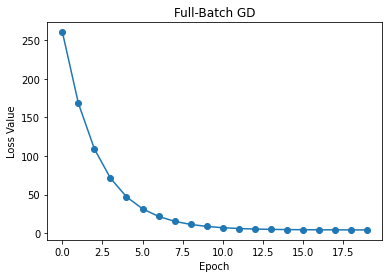

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.30314 sec


In [14]:
# Test 1
X, y = model.data_generation(true_a=20, true_b=5)

n_epochs, lr = 100, 1e-1

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

Training Starts...
Full-Batch GD
========== Epoch 1/100 ==========
Loss > 458589.377513077226467
Params > coef: 54.33 / bias: 89.42
Loss Difference between Successive Epochs: 99.541 %
========== Epoch 2/100 ==========
Loss > 410541.394070804875810
Params > coef: 82.04 / bias: 157.01
Loss Difference between Successive Epochs: 10.477 %
========== Epoch 3/100 ==========
Loss > 379750.870595966931432
Params > coef: 104.26 / bias: 211.11
Loss Difference between Successive Epochs: 7.5 %
========== Epoch 4/100 ==========
Loss > 360019.375192601641174
Params > coef: 122.09 / bias: 254.40
Loss Difference between Successive Epochs: 5.196 %
========== Epoch 5/100 ==========
Loss > 347374.808594445174094
Params > coef: 136.38 / bias: 289.04
Loss Difference between Successive Epochs: 3.512 %
========== Epoch 6/100 ==========
Loss > 339271.751228924491443
Params > coef: 147.85 / bias: 316.77
Loss Difference between Successive Epochs: 2.333 %
========== Epoch 7/100 ==========
Loss > 334079.0313515468

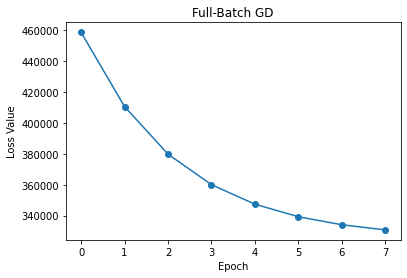

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.18855 sec


In [15]:
# Test 2
X, y = model.data_generation_quad(true_a=20, true_b=5)

n_epochs, lr = 100, 1e-1

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

In [16]:
# ----- Test SGD -----
# batch size가 1로 매우 작기 때문에 loss가 일정하게 줄어들지는 않는다.

In [17]:
model = SampleModel(a=0.5, b=0.5)

Training Starts...
Mini-Batch SGD w Batch Size: 1
========== Epoch 1/100 ==========
Loss > 193.0898319749
Params > coef: 6.28 / bias: 5.84
Loss Difference between Successive Epochs: 100.0 %
========== Epoch 2/100 ==========
Loss > 49.2826496597
Params > coef: 19.73 / bias: 11.73
Loss Difference between Successive Epochs: 74.477 %
========== Epoch 3/100 ==========
Loss > 29.4656105037
Params > coef: 19.68 / bias: 10.04
Loss Difference between Successive Epochs: 40.211 %
========== Epoch 4/100 ==========
Loss > 23.7888094019
Params > coef: 18.53 / bias: 9.20
Loss Difference between Successive Epochs: 19.266 %
========== Epoch 5/100 ==========
Loss > 15.3054294089
Params > coef: 19.14 / bias: 8.25
Loss Difference between Successive Epochs: 35.661 %
========== Epoch 6/100 ==========
Loss > 12.5974616561
Params > coef: 19.67 / bias: 7.91
Loss Difference between Successive Epochs: 17.693 %
========== Epoch 7/100 ==========
Loss > 12.3761051273
Params > coef: 19.62 / bias: 7.87
Loss Differenc

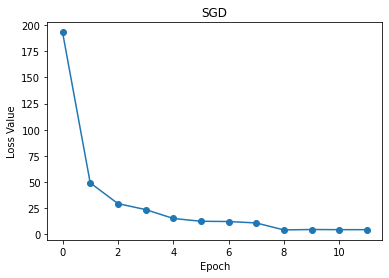

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.20339 sec


In [18]:
# Test 1
X, y = model.data_generation(true_a=20, true_b=5)

n_epochs, lr, batch_size = 100, 1e-1, 1

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr, batch_size=batch_size)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

Training Starts...
Mini-Batch SGD w Batch Size: 1
========== Epoch 1/100 ==========
Loss > 491470.2248492555
Params > coef: -1.61 / bias: 69.01
Loss Difference between Successive Epochs: 99.509 %
========== Epoch 2/100 ==========
Loss > 454128.5439796337
Params > coef: 20.54 / bias: 112.05
Loss Difference between Successive Epochs: 7.598 %
========== Epoch 3/100 ==========
Loss > 395398.7612388755
Params > coef: 74.91 / bias: 188.49
Loss Difference between Successive Epochs: 12.932 %
========== Epoch 4/100 ==========
Loss > 404016.8121142362
Params > coef: 88.01 / bias: 165.26
Loss Difference between Successive Epochs: -2.18 %
========== Epoch 5/100 ==========
Loss > 569921.8923521158
Params > coef: 694.14 / bias: 477.53
Loss Difference between Successive Epochs: -41.064 %
========== Epoch 6/100 ==========
Loss > 544795.4006608303
Params > coef: 662.44 / bias: 516.62
Loss Difference between Successive Epochs: 4.409 %
========== Epoch 7/100 ==========
Loss > 461453.5085822370
Params > c

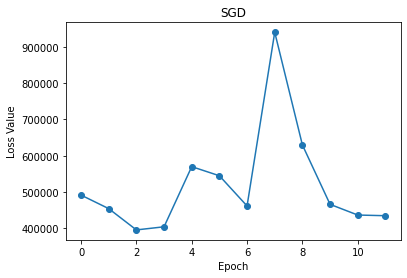

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.18021 sec


In [20]:
# Test 2
X, y = model.data_generation_quad(true_a=20, true_b=5)

n_epochs, lr, batch_size = 100, 1e-1, 1

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr, batch_size=batch_size)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

In [21]:
# ----- Test Mini-Batch SGD -----

In [23]:
model = SampleModel(a=0.5, b=0.5)

Training Starts...
Mini-Batch SGD w Batch Size: 1000
========== Epoch 1/100 ==========
Loss > 256.9657529093
Params > coef: 4.44 / bias: 1.43
Loss Difference between Successive Epochs: 100.0 %
========== Epoch 2/100 ==========
Loss > 166.2478607849
Params > coef: 7.55 / bias: 2.08
Loss Difference between Successive Epochs: 35.303 %
========== Epoch 3/100 ==========
Loss > 106.7839333336
Params > coef: 10.10 / bias: 2.65
Loss Difference between Successive Epochs: 35.768 %
========== Epoch 4/100 ==========
Loss > 70.0854040255
Params > coef: 12.07 / bias: 3.08
Loss Difference between Successive Epochs: 34.367 %
========== Epoch 5/100 ==========
Loss > 46.9571381469
Params > coef: 13.59 / bias: 3.49
Loss Difference between Successive Epochs: 33.0 %
========== Epoch 6/100 ==========
Loss > 30.2264906899
Params > coef: 14.99 / bias: 3.80
Loss Difference between Successive Epochs: 35.63 %
========== Epoch 7/100 ==========
Loss > 20.9780076461
Params > coef: 15.97 / bias: 4.03
Loss Difference

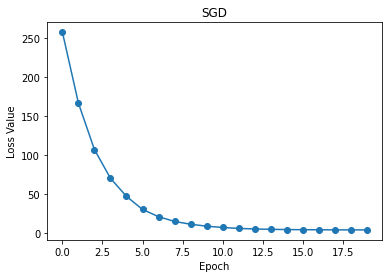

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.23664 sec


In [24]:
# Test 1
X, y = model.data_generation(true_a=20, true_b=5)

n_epochs, lr, batch_size = 100, 1e-1, 1000

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr, batch_size=batch_size)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

Training Starts...
Mini-Batch SGD w Batch Size: 1000
========== Epoch 1/100 ==========
Loss > 460442.1422585119
Params > coef: 65.66 / bias: 89.31
Loss Difference between Successive Epochs: 99.54 %
========== Epoch 2/100 ==========
Loss > 411795.3013356184
Params > coef: 103.80 / bias: 154.32
Loss Difference between Successive Epochs: 10.565 %
========== Epoch 3/100 ==========
Loss > 384816.1042081551
Params > coef: 111.20 / bias: 206.12
Loss Difference between Successive Epochs: 6.552 %
========== Epoch 4/100 ==========
Loss > 361607.6422110149
Params > coef: 131.44 / bias: 257.06
Loss Difference between Successive Epochs: 6.031 %
========== Epoch 5/100 ==========
Loss > 347229.5146669057
Params > coef: 153.15 / bias: 296.07
Loss Difference between Successive Epochs: 3.976 %
========== Epoch 6/100 ==========
Loss > 340279.8681946677
Params > coef: 166.20 / bias: 320.56
Loss Difference between Successive Epochs: 2.001 %
========== Epoch 7/100 ==========
Loss > 335929.6520689180
Params 

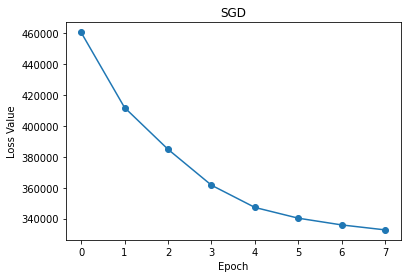

Training Ends...

Trained with 100 epochs, 0.1 learning rate
Time Cost: 0.17843 sec


In [25]:
# Test 2
X, y = model.data_generation_quad(true_a=20, true_b=5)

n_epochs, lr, batch_size = 100, 1e-1, 1000

start_time = time.time()

model.run(X, y, train=True, n_epochs=n_epochs, lr=lr, batch_size=batch_size)
loss = model.compute_loss(X, y)

end_time = time.time()

print("Training Ends...")
print()
print("Trained with {} epochs, {} learning rate".format(n_epochs, lr))
print("Time Cost: {:.5f} sec".format(end_time-start_time))

In [27]:
# ----- 참고 -----
# - 직전 epoch와의 loss difference를 계산하는 코드와 100 epoch동안의 Loss값을 기록하여 그래프로 나타내는 코드를 삽입하였다.
# - loss difference의 결과값은 '(직전 loss - 현재 loss) / 직전 loss * 100'으로 계산하였고, Loss Difference between Successive Epochs'로 값을 출력하였다.
# - SGD optimal loss value의 기준이 적절한가?
#     - SGD의 경우 Loss의 증감이 반복되기 때문에 loss difference가 1%미만할 때의 loss를 optimal이라고 하는 것보다는 loss가 특정 값 아래일 때 학습을 중단하고 그 지점에서의 loss를 optimal이라고 한다면, 다른 결과가 나왔을 수 있을 것 같다.
#     - 그러나 우선, 문제에서 요구한 것처럼 optimal loss value를 loss difference가 1% 미만이 되는 지점에서의 loss로 지정하였다.